# Discrete Error‑Correcting Coded VAE for scRNA‑seq (codedVAE + scVI)

This notebook replicates the core idea of the codedVAE paper (OpenReview `66P2ioAYY4`)
in a **scVI** framework for single‑cell transcriptomics.

1. Load a toy heart atlas dataset (scvi‑tools).
2. Train a standard continuous‑latent scVI model.
3. Implement a discrete‑latent model that uses a **repetition code** (10 info bits → 50 code bits).
4. Compare latent spaces, reconstruction quality, and verify the correctness of the coded scheme.

In [1]:
# Install required packages (run once)
!pip install --quiet scvi-tools scanpy matplotlib umap-learn

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.5 MB/s eta 0:00:00
   

In [2]:
# Libraries

import os
import math
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Bernoulli

import scvi
from scvi import REGISTRY_KEYS
from scvi.model import SCVI
from scvi.model._utils import get_max_epochs_heuristic
from scvi.module import VAE
from scvi.model.base import (
    BaseModelClass,
    VAEMixin,
    RNASeqMixin,
    ArchesMixin,
    UnsupervisedTrainingMixin,
    BaseMinifiedModeModelClass,
)
from scvi.dataloaders import DataSplitter
from scvi.train import TrainingPlan, TrainRunner

from scvi.model._utils import _init_library_size
from scvi.model.base import UnsupervisedTrainingMixin
from scvi.model.utils import get_minified_adata_scrna
from scvi.module import VAE
from scvi.utils import setup_anndata_dsp

from scvi.data import AnnDataManager
from scvi.data.fields import (
    LayerField,
    NumericalObsField,
    CategoricalObsField,
    CategoricalJointObsField,
    NumericalJointObsField
)

from __future__ import annotations

import logging
import warnings
from typing import TYPE_CHECKING

import numpy as np
import torch
from torch.nn.functional import one_hot

from scvi import REGISTRY_KEYS, settings
from scvi.data._constants import ADATA_MINIFY_TYPE
from scvi.module._constants import MODULE_KEYS
from scvi.module.base import (
    BaseMinifiedModeModuleClass,
    EmbeddingModuleMixin,
    LossOutput,
    auto_move_data,
)
from scvi.utils import unsupported_if_adata_minified

if TYPE_CHECKING:
    from collections.abc import Callable
    from typing import Literal

    from torch.distributions import Distribution

logger = logging.getLogger(__name__)


import matplotlib.pyplot as plt
import umap

In [3]:
import os
from google.colab import drive

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/scvi_data'
os.makedirs(save_dir, exist_ok=True)

Mounted at /content/drive


# 1. Load and Prepare Toy Dataset

In [4]:
# Load heart cell atlas subsampled
adata = scvi.data.heart_cell_atlas_subsampled()
print(adata)

INFO     Downloading file at data/hca_subsampled_20k.h5ad                                                          


Downloading...:   0%|          | 0/65714.0 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'


In [5]:
# Basic filtering and HVG selection
sc.pp.filter_genes(adata, min_counts=3) # Minimum gene expressed in 3 cells
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()
adata.shape

(18641, 2000)

# 2. Baseline scVI

In [6]:
from pathlib import Path

my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_test_official")
if my_file.exists():
    cont_model = scvi.model.SCVI.load(my_file, adata=adata)
else:
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    cont_model = scvi.model.SCVI(adata, n_latent=10, n_hidden=128, n_layers=2)
    cont_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})
    model_dir = os.path.join(save_dir, "scvi_model_cont")
    cont_model.save(model_dir, overwrite=True)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model_test_official/model.pt already downloaded                


# 3. Discrete Uncoded scVI

### Helper functions (scVI)

In [7]:
def _init_library_size(
    adata_manager: AnnDataManager, n_batch: dict
) -> tuple[np.ndarray, np.ndarray]:
    """Computes and returns library size.

    Parameters
    ----------
    adata_manager
        :class:`~scvi.data.AnnDataManager` object setup with :class:`~scvi.model.SCVI`.
    n_batch
        Number of batches.

    Returns
    -------
    type
        Tuple of two 1 x n_batch ``np.ndarray`` containing the means and variances
        of library size in each batch in adata.

        If a certain batch is not present in the adata, the mean defaults to 0,
        and the variance defaults to 1. These defaults are arbitrary placeholders that
        should not be used in any downstream computation.
    """
    data = adata_manager.get_from_registry(REGISTRY_KEYS.X_KEY)
    batch_indices = adata_manager.get_from_registry(REGISTRY_KEYS.BATCH_KEY)

    library_log_means = np.zeros(n_batch)
    library_log_vars = np.ones(n_batch)

    for i_batch in np.unique(batch_indices):
        idx_batch = np.squeeze(batch_indices == i_batch)
        batch_data = data[idx_batch.nonzero()[0]]
        sum_counts = batch_data.sum(axis=1)
        masked_log_sum = np.ma.log(sum_counts)
        if np.ma.is_masked(masked_log_sum):
            warnings.warn(
                "This dataset has some empty cells, this might fail inference."
                "Data should be filtered with `scanpy.pp.filter_cells()`",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )

        log_counts = masked_log_sum.filled(0)
        library_log_means[i_batch] = np.mean(log_counts).astype(np.float32)
        library_log_vars[i_batch] = np.var(log_counts).astype(np.float32)

    return library_log_means.reshape(1, -1), library_log_vars.reshape(1, -1)



### Helper functions (codedVAE)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import custom_bwd, custom_fwd

class DifferentiableClamp(torch.autograd.Function):
    """
    https://discuss.pytorch.org/t/exluding-torch-clamp-from-backpropagation-as-tf-stop-gradient-in-tensorflow/52404/6
    In the forward pass this operation behaves like torch.clamp.
    But in the backward pass its gradient is 1 everywhere, as if instead of clamp one had used the identity function.
    """

    @staticmethod
    @custom_fwd(device_type='cuda')
    def forward(ctx, input, min, max):
        return input.clamp(min=min, max=max)

    @staticmethod
    @custom_bwd(device_type='cuda')
    def backward(ctx, grad_output):
        return grad_output.clone(), None, None


def dclamp(input, min, max):
    """
    https://discuss.pytorch.org/t/exluding-torch-clamp-from-backpropagation-as-tf-stop-gradient-in-tensorflow/52404/6
    Like torch.clamp, but with a constant 1-gradient.
    :param input: The input that is to be clamped.
    :param min: The minimum value of the output.
    :param max: The maximum value of the output.
    """
    return DifferentiableClamp.apply(input, min, max)

In [9]:
# Utility function for forward function
def sample_from_qz_given_x(qi, beta=torch.tensor(10), n_samples=1):

    """
    This method implements the DVAE's reparameterization trick.

    Parameters
        ----------
        qi : torch.tensor
            Probability of bits being 1.
        beta : torch.tensor
            Temperature term that controls the decay of the exponentials in the smoothing transformation. Default to 10.
        n_samples: int, optional
            Number of samples used to estimate the ELBO. Default to 1.

        Returns
        -------
        q_z: torch.tensor
            Sampled z.
    """

    # Here we are implementing the reparameterization trick from the DiscreteVAE

    # Sanity check
    assert torch.any(qi < 0)==False, "Negative value encountered in bit probabilities."
    assert torch.any(qi > 1)==False, "Value larger than 1 encountered in bit probabilities."


    # Obtain n_samples from q(z|x) {REPARAMETERIZATION}
    epsilon = 1e-6

    # Bit probabilities q(c_i=1|x)
    qi = qi.unsqueeze(2).repeat(1, 1, n_samples)
    ones = torch.ones((qi.shape)).to(qi.device)

    # Clamp to avoid divisions by 0 in the reparameterization
    qi = dclamp(qi, 0, 1-1e-3)

    # Sample from U(0,1)
    rho = torch.rand(qi.shape).to(qi.device)

    # Reparameterization
    b = (rho+torch.exp(-beta)*(qi-rho))/(ones-qi) - ones
    c = -(qi*torch.exp(-beta))/(ones-qi)

    dif = torch.sqrt(torch.pow(b, 2) - 4*c) - b
    dif = torch.where(dif <= 0, epsilon, dif)   # avoid negative or zero values due to numerical imprecission

    q_z = (-1/beta)*torch.log(dif/2) # shape [N, K, n_samples]

    # Sanity check
    assert torch.any(torch.isinf(q_z))==False, "Invalid q(z|x) value (inf)."
    assert torch.any(torch.isnan(q_z))==False, "Invalid q(z|x) value (nan)."

    return q_z


In [44]:
# Utility function for loss
import torch.distributions as dist
def kl_div_bernoulli(q_probs, p_probs):

    """
    Compute KL Divergence D_KL(q|p) between two Bernoulli distributions.

    Parameters
        ----------
        q_probs : torch.tensor
            Probabilities that define the q distribution.
        p_probs : torch.tensor
           Probabilities that define the p distribution.

        Returns
        -------
        kl_div : torch.tensor
            Kullback-Leibler divergence between the given distributions.
    """

    q = dist.Bernoulli(dclamp(q_probs, min=0, max=1-1e-3)) # clamp to avoid numerical instabilities
    p = dist.Bernoulli(p_probs)

    kl_div = dist.kl.kl_divergence(q, p)

    kl_div = torch.sum(kl_div, dim=1)

    return kl_div

### UncodedSCVIModule

Changes made
- Added `self.beta` temperature term at default value 15
- Added `'discrete'` as an option to `self.latent_distribution`
- Change encoder output

In [45]:
class UncodedSCVIModule(EmbeddingModuleMixin, BaseMinifiedModeModuleClass):
    """Variational auto-encoder :cite:p:`Lopez18`.

    Parameters
    ----------
    n_input
        Number of input features.
    n_batch
        Number of batches. If ``0``, no batch correction is performed.
    n_labels
        Number of labels.
    n_hidden
        Number of nodes per hidden layer. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_latent
        Dimensionality of the latent space.
    n_layers
        Number of hidden layers. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_continuous_cov
        Number of continuous covariates.
    n_cats_per_cov
        A list of integers containing the number of categories for each categorical covariate.
    dropout_rate
        Dropout rate. Passed into :class:`~scvi.nn.Encoder` but not :class:`~scvi.nn.DecoderSCVI`.
    dispersion
        Flexibility of the dispersion parameter when ``gene_likelihood`` is either ``"nb"`` or
        ``"zinb"``. One of the following:

        * ``"gene"``: parameter is constant per gene across cells.
        * ``"gene-batch"``: parameter is constant per gene per batch.
        * ``"gene-label"``: parameter is constant per gene per label.
        * ``"gene-cell"``: parameter is constant per gene per cell.
    log_variational
        If ``True``, use :func:`~torch.log1p` on input data before encoding for numerical stability
        (not normalization).
    gene_likelihood
        Distribution to use for reconstruction in the generative process. One of the following:

        * ``"nb"``: :class:`~scvi.distributions.NegativeBinomial`.
        * ``"zinb"``: :class:`~scvi.distributions.ZeroInflatedNegativeBinomial`.
        * ``"poisson"``: :class:`~scvi.distributions.Poisson`.
        * ``"normal"``: :class:`~torch.distributions.Normal`.
    latent_distribution
        Distribution to use for the latent space. One of the following:

        * ``"normal"``: isotropic normal.
        * ``"ln"``: logistic normal with normal params N(0, 1).
    encode_covariates
        If ``True``, covariates are concatenated to gene expression prior to passing through
        the encoder(s). Else, only gene expression is used.
    deeply_inject_covariates
        If ``True`` and ``n_layers > 1``, covariates are concatenated to the outputs of hidden
        layers in the encoder(s) (if ``encoder_covariates`` is ``True``) and the decoder prior to
        passing through the next layer.
    batch_representation
        ``EXPERIMENTAL`` Method for encoding batch information. One of the following:

        * ``"one-hot"``: represent batches with one-hot encodings.
        * ``"embedding"``: represent batches with continuously-valued embeddings using
          :class:`~scvi.nn.Embedding`.

        Note that batch representations are only passed into the encoder(s) if
        ``encode_covariates`` is ``True``.
    use_batch_norm
        Specifies where to use :class:`~torch.nn.BatchNorm1d` in the model. One of the following:

        * ``"none"``: don't use batch norm in either encoder(s) or decoder.
        * ``"encoder"``: use batch norm only in the encoder(s).
        * ``"decoder"``: use batch norm only in the decoder.
        * ``"both"``: use batch norm in both encoder(s) and decoder.

        Note: if ``use_layer_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_layer_norm
        Specifies where to use :class:`~torch.nn.LayerNorm` in the model. One of the following:

        * ``"none"``: don't use layer norm in either encoder(s) or decoder.
        * ``"encoder"``: use layer norm only in the encoder(s).
        * ``"decoder"``: use layer norm only in the decoder.
        * ``"both"``: use layer norm in both encoder(s) and decoder.

        Note: if ``use_batch_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_size_factor_key
        If ``True``, use the :attr:`~anndata.AnnData.obs` column as defined by the
        ``size_factor_key`` parameter in the model's ``setup_anndata`` method as the scaling
        factor in the mean of the conditional distribution. Takes priority over
        ``use_observed_lib_size``.
    use_observed_lib_size
        If ``True``, use the observed library size for RNA as the scaling factor in the mean of the
        conditional distribution.
    extra_payload_autotune
        If ``True``, will return extra matrices in the loss output to be used during autotune
    library_log_means
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of means of the log library sizes that
        parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    library_log_vars
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of variances of the log library sizes
        that parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    var_activation
        Callable used to ensure positivity of the variance of the variational distribution. Passed
        into :class:`~scvi.nn.Encoder`. Defaults to :func:`~torch.exp`.
    extra_encoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.Encoder`.
    extra_decoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.DecoderSCVI`.
    batch_embedding_kwargs
        Keyword arguments passed into :class:`~scvi.nn.Embedding` if ``batch_representation`` is
        set to ``"embedding"``.

    """

    def __init__(
        self,
        n_input: int,
        n_batch: int = 0,
        n_labels: int = 0,
        n_hidden: int = 128,
        n_latent: int = 10,
        n_layers: int = 1,
        n_continuous_cov: int = 0,
        n_cats_per_cov: list[int] | None = None,
        dropout_rate: float = 0.1,
        beta: int = 10,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        log_variational: bool = True,
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln", "discrete"] = "normal", # ADD DVAE OPTION
        encode_covariates: bool = False,
        deeply_inject_covariates: bool = True,
        batch_representation: Literal["one-hot", "embedding"] = "one-hot",
        use_batch_norm: Literal["encoder", "decoder", "none", "both"] = "both",
        use_layer_norm: Literal["encoder", "decoder", "none", "both"] = "none",
        use_size_factor_key: bool = False,
        use_observed_lib_size: bool = True,
        extra_payload_autotune: bool = False,
        library_log_means: np.ndarray | None = None,
        library_log_vars: np.ndarray | None = None,
        var_activation: Callable[[torch.Tensor], torch.Tensor] = None,
        extra_encoder_kwargs: dict | None = None,
        extra_decoder_kwargs: dict | None = None,
        batch_embedding_kwargs: dict | None = None,
    ):
        from scvi.nn import DecoderSCVI, Encoder

        super().__init__()

        self.dispersion = dispersion
        self.n_latent = n_latent
        self.beta = beta
        self.log_variational = log_variational
        self.gene_likelihood = gene_likelihood
        self.n_batch = n_batch
        self.n_labels = n_labels
        self.latent_distribution = latent_distribution
        self.encode_covariates = encode_covariates
        self.use_size_factor_key = use_size_factor_key
        self.use_observed_lib_size = use_size_factor_key or use_observed_lib_size
        self.extra_payload_autotune = extra_payload_autotune



        if not self.use_observed_lib_size:
            if library_log_means is None or library_log_vars is None:
                raise ValueError(
                    "If not using observed_lib_size, "
                    "must provide library_log_means and library_log_vars."
                )

            self.register_buffer("library_log_means", torch.from_numpy(library_log_means).float())
            self.register_buffer("library_log_vars", torch.from_numpy(library_log_vars).float())

        if self.dispersion == "gene":
            self.px_r = torch.nn.Parameter(torch.randn(n_input))
        elif self.dispersion == "gene-batch":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_batch))
        elif self.dispersion == "gene-label":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_labels))
        elif self.dispersion == "gene-cell":
            pass
        else:
            raise ValueError(
                "`dispersion` must be one of 'gene', 'gene-batch', 'gene-label', 'gene-cell'."
            )

        self.batch_representation = batch_representation
        if self.batch_representation == "embedding":
            self.init_embedding(REGISTRY_KEYS.BATCH_KEY, n_batch, **(batch_embedding_kwargs or {}))
            batch_dim = self.get_embedding(REGISTRY_KEYS.BATCH_KEY).embedding_dim
        elif self.batch_representation != "one-hot":
            raise ValueError("`batch_representation` must be one of 'one-hot', 'embedding'.")

        use_batch_norm_encoder = use_batch_norm == "encoder" or use_batch_norm == "both"
        use_batch_norm_decoder = use_batch_norm == "decoder" or use_batch_norm == "both"
        use_layer_norm_encoder = use_layer_norm == "encoder" or use_layer_norm == "both"
        use_layer_norm_decoder = use_layer_norm == "decoder" or use_layer_norm == "both"

        n_input_encoder = n_input + n_continuous_cov * encode_covariates
        if self.batch_representation == "embedding":
            n_input_encoder += batch_dim * encode_covariates
            cat_list = list([] if n_cats_per_cov is None else n_cats_per_cov)
        else:
            cat_list = [n_batch] + list([] if n_cats_per_cov is None else n_cats_per_cov)

        encoder_cat_list = cat_list if encode_covariates else None
        _extra_encoder_kwargs = extra_encoder_kwargs or {}
        self.z_encoder = Encoder(
            n_input_encoder,
            n_latent,
            n_cat_list=encoder_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            distribution=latent_distribution,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        # l encoder goes from n_input-dimensional data to 1-d library size
        self.l_encoder = Encoder(
            n_input_encoder,
            1,
            n_layers=1,
            n_cat_list=encoder_cat_list,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        n_input_decoder = n_latent + n_continuous_cov
        if self.batch_representation == "embedding":
            n_input_decoder += batch_dim

        _extra_decoder_kwargs = extra_decoder_kwargs or {}
        self.decoder = DecoderSCVI(
            n_input_decoder,
            n_input,
            n_cat_list=cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_decoder,
            use_layer_norm=use_layer_norm_decoder,
            scale_activation="softplus" if use_size_factor_key else "softmax",
            **_extra_decoder_kwargs,
        )

    def _get_inference_input(
        self,
        tensors: dict[str, torch.Tensor | None],
        full_forward_pass: bool = False,
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the inference process."""
        if full_forward_pass or self.minified_data_type is None:
            loader = "full_data"
        elif self.minified_data_type in [
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR,
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR_WITH_COUNTS,
        ]:
            loader = "minified_data"
        else:
            raise NotImplementedError(f"Unknown minified-data type: {self.minified_data_type}")

        if loader == "full_data":
            return {
                MODULE_KEYS.X_KEY: tensors[REGISTRY_KEYS.X_KEY],
                MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
                MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
                MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            }
        else:
            return {
                MODULE_KEYS.QZM_KEY: tensors[REGISTRY_KEYS.LATENT_QZM_KEY],
                MODULE_KEYS.QZV_KEY: tensors[REGISTRY_KEYS.LATENT_QZV_KEY],
                REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            }

    def _get_generative_input(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the generative process."""
        size_factor = tensors.get(REGISTRY_KEYS.SIZE_FACTOR_KEY, None)
        if size_factor is not None:
            size_factor = torch.log(size_factor)

        return {
            MODULE_KEYS.Z_KEY: inference_outputs[MODULE_KEYS.Z_KEY],
            MODULE_KEYS.LIBRARY_KEY: inference_outputs[MODULE_KEYS.LIBRARY_KEY],
            MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
            MODULE_KEYS.Y_KEY: tensors[REGISTRY_KEYS.LABELS_KEY],
            MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
            MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            MODULE_KEYS.SIZE_FACTOR_KEY: size_factor,
        }

    def _compute_local_library_params(
        self,
        batch_index: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Computes local library parameters.

        Compute two tensors of shape (batch_index.shape[0], 1) where each
        element corresponds to the mean and variances, respectively, of the
        log library sizes in the batch the cell corresponds to.
        """
        from torch.nn.functional import linear

        n_batch = self.library_log_means.shape[1]
        local_library_log_means = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_means
        )

        local_library_log_vars = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_vars
        )

        return local_library_log_means, local_library_log_vars

    @auto_move_data
    def _regular_inference(
        self,
        x: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        n_samples: int = 1,
    ) -> dict[str, torch.Tensor | Distribution | None]:
        """Run the regular inference process."""
        x_ = x
        if self.use_observed_lib_size:
            library = torch.log(x.sum(1)).unsqueeze(1)
        if self.log_variational:
            x_ = torch.log1p(x_)

        if cont_covs is not None and self.encode_covariates:
            encoder_input = torch.cat((x_, cont_covs), dim=-1)
        else:
            encoder_input = x_
        if cat_covs is not None and self.encode_covariates:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        # ADDITION: SIGMOID AND CLAMP TO TURN ENCODER OUTPUT INTO BIT PROBABILITY
        if self.latent_distribution == "discrete":
            # Encoder outputs a Normal distribution (loc, scale)
            qz_dist, _ = self.z_encoder(encoder_input, batch_index, *categorical_input)
            logits = qz_dist.loc                     # shape (batch, n_latent)
            qi = torch.sigmoid(logits)               # probability of bit=1
            qi = dclamp(qi, 0.001, 0.999)            # numerical stability
            # Sample using the Concrete relaxation
            z_sample = sample_from_qz_given_x(qi, beta=torch.tensor(self.beta), n_samples=n_samples)
            # Reshape: if n_samples > 1, z_sample is (batch, n_latent, n_samples)
            if n_samples == 1:
                z = z_sample.squeeze(-1)
            else:
                z = z_sample.permute(2, 0, 1)        # (n_samples, batch, n_latent)
            # Store qi for KL computation (we will treat qz as a tensor of probabilities)
            qz = qi
        else:
            if self.batch_representation == "embedding" and self.encode_covariates:
                batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
                encoder_input = torch.cat([encoder_input, batch_rep], dim=-1)
                qz, z = self.z_encoder(encoder_input, *categorical_input)
            else:
                qz, z = self.z_encoder(encoder_input, batch_index, *categorical_input)

        ql = None
        if not self.use_observed_lib_size:
            if self.batch_representation == "embedding":
                ql, library_encoded = self.l_encoder(encoder_input, *categorical_input)
            else:
                ql, library_encoded = self.l_encoder(
                    encoder_input, batch_index, *categorical_input
                )
            library = library_encoded

        if n_samples > 1:
            untran_z = qz.sample((n_samples,))
            z = self.z_encoder.z_transformation(untran_z)
            if self.use_observed_lib_size:
                library = library.unsqueeze(0).expand(
                    (n_samples, library.size(0), library.size(1))
                )
            else:
                library = ql.sample((n_samples,))

        return {
            MODULE_KEYS.Z_KEY: z,
            MODULE_KEYS.QZ_KEY: qz,
            MODULE_KEYS.QL_KEY: ql,
            MODULE_KEYS.LIBRARY_KEY: library,
        }

    @auto_move_data
    # def _cached_inference(
    #     self,
    #     qzm: torch.Tensor,
    #     qzv: torch.Tensor,
    #     observed_lib_size: torch.Tensor,
    #     n_samples: int = 1,
    # ) -> dict[str, torch.Tensor | None]:
    #     """Run the cached inference process."""
    #     from torch.distributions import Normal

    #     qz = Normal(qzm, qzv.sqrt())
    #     # use dist.sample() rather than rsample because we aren't optimizing the z here
    #     untran_z = qz.sample() if n_samples == 1 else qz.sample((n_samples,))
    #     z = self.z_encoder.z_transformation(untran_z)
    #     library = torch.log(observed_lib_size)
    #     if n_samples > 1:
    #         library = library.unsqueeze(0).expand((n_samples, library.size(0), library.size(1)))

    #     return {
    #         MODULE_KEYS.Z_KEY: z,
    #         MODULE_KEYS.QZ_KEY: qz,
    #         MODULE_KEYS.QL_KEY: None,
    #         MODULE_KEYS.LIBRARY_KEY: library,
    #     }

    @auto_move_data
    def generative(
        self,
        z: torch.Tensor,
        library: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        size_factor: torch.Tensor | None = None,
        y: torch.Tensor | None = None,
        transform_batch: torch.Tensor | None = None,
    ) -> dict[str, Distribution | None]:
        """Run the generative process."""
        from torch.nn.functional import linear

        from scvi.distributions import (
            NegativeBinomial,
            Normal,
            Poisson,
            ZeroInflatedNegativeBinomial,
        )

        # TODO: refactor forward function to not rely on y
        # Likelihood distribution
        if cont_covs is None:
            decoder_input = z
        elif z.dim() != cont_covs.dim():
            decoder_input = torch.cat(
                [z, cont_covs.unsqueeze(0).expand(z.size(0), -1, -1)], dim=-1
            )
        else:
            decoder_input = torch.cat([z, cont_covs], dim=-1)

        if cat_covs is not None:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if transform_batch is not None:
            batch_index = torch.ones_like(batch_index) * transform_batch

        if not self.use_size_factor_key:
            size_factor = library

        if self.batch_representation == "embedding":
            batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
            decoder_input = torch.cat([decoder_input, batch_rep], dim=-1)
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                *categorical_input,
                y,
            )
        else:
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                batch_index,
                *categorical_input,
                y,
            )

        if self.dispersion == "gene-label":
            px_r = linear(
                one_hot(y.squeeze(-1), self.n_labels).float(), self.px_r
            )  # px_r gets transposed - last dimension is nb genes
        elif self.dispersion == "gene-batch":
            px_r = linear(one_hot(batch_index.squeeze(-1), self.n_batch).float(), self.px_r)
        elif self.dispersion == "gene":
            px_r = self.px_r

        px_r = torch.exp(px_r)

        if self.gene_likelihood == "zinb":
            px = ZeroInflatedNegativeBinomial(
                mu=px_rate,
                theta=px_r,
                zi_logits=px_dropout,
                scale=px_scale,
            )
        elif self.gene_likelihood == "nb":
            px = NegativeBinomial(mu=px_rate, theta=px_r, scale=px_scale)
        elif self.gene_likelihood == "poisson":
            px = Poisson(rate=px_rate, scale=px_scale)
        elif self.gene_likelihood == "normal":
            px = Normal(px_rate, px_r, normal_mu=px_scale)

        # Priors
        if self.use_observed_lib_size:
            pl = None
        else:
            (
                local_library_log_means,
                local_library_log_vars,
            ) = self._compute_local_library_params(batch_index)
            pl = Normal(local_library_log_means, local_library_log_vars.sqrt())

        # ADDITION: HANDLE PZ FOR DISCRETE
        if self.latent_distribution == "discrete":
            # Prior: independent Bernoulli(0.5) for each bit
            # Return a tensor of prior probabilities (broadcastable to batch size)
            pz = torch.full((1, z.size(-1)), 0.5, device=z.device)
        else:
            pz = Normal(torch.zeros_like(z), torch.ones_like(z))

        return {
            MODULE_KEYS.PX_KEY: px,
            MODULE_KEYS.PL_KEY: pl,
            MODULE_KEYS.PZ_KEY: pz,
        }

    @unsupported_if_adata_minified
    def loss(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
        generative_outputs: dict[str, Distribution | None],
        kl_weight: torch.tensor | float = 1.0,
    ) -> LossOutput:
        """Compute the loss."""
        from torch.distributions import kl_divergence
        from torch.distributions import Bernoulli # prior

        x = tensors[REGISTRY_KEYS.X_KEY]
        qz = inference_outputs[MODULE_KEYS.QZ_KEY]
        pz = generative_outputs[MODULE_KEYS.PZ_KEY]

        # ADDITION: KL DIVERGENCE FOR DISCRETE
        if self.latent_distribution == "discrete":
            # qz: tensor of probabilities (batch, n_latent)
            # pz: tensor of prior probabilities (1, n_latent) or (batch, n_latent)
            # KL divergence for Bernoulli: KL(q||p) = q*log(q/p) + (1-q)*log((1-q)/(1-p))
            # eps = 1e-8
            # kl_divergence_z = qz * torch.log(qz / pz + eps) + (1 - qz) * torch.log((1 - qz) / (1 - pz) + eps)
            # kl_divergence_z = kl_divergence_z.sum(dim=-1)
            kl_divergence_z = kl_div_bernoulli(qz, pz)

        else:
            kl_divergence_z = kl_divergence(qz, pz).sum(dim=-1)


        if not self.use_observed_lib_size:
            kl_divergence_l = kl_divergence(
                inference_outputs[MODULE_KEYS.QL_KEY], generative_outputs[MODULE_KEYS.PL_KEY]
            ).sum(dim=1)
        else:
            kl_divergence_l = torch.zeros_like(kl_divergence_z)

        reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)

        kl_local_for_warmup = kl_divergence_z
        kl_local_no_warmup = kl_divergence_l

        weighted_kl_local = kl_weight * kl_local_for_warmup + kl_local_no_warmup

        loss = torch.mean(reconst_loss + weighted_kl_local)

        # a payload to be used during autotune
        if self.extra_payload_autotune:
            extra_metrics_payload = {
                "z": inference_outputs["z"],
                "batch": tensors[REGISTRY_KEYS.BATCH_KEY],
                "labels": tensors[REGISTRY_KEYS.LABELS_KEY],
            }
        else:
            extra_metrics_payload = {}

        return LossOutput(
            loss=loss,
            reconstruction_loss=reconst_loss,
            kl_local={
                MODULE_KEYS.KL_L_KEY: kl_divergence_l,
                MODULE_KEYS.KL_Z_KEY: kl_divergence_z,
            },
            extra_metrics=extra_metrics_payload,
        )

    @torch.inference_mode()
    def sample(
        self,
        tensors: dict[str, torch.Tensor],
        n_samples: int = 1,
        max_poisson_rate: float = 1e8,
        generative_kwargs: dict | None = None,
    ) -> torch.Tensor:
        r"""Generate predictive samples from the posterior predictive distribution.

        The posterior predictive distribution is denoted as :math:`p(\hat{x} \mid x)`, where
        :math:`x` is the input data and :math:`\hat{x}` is the sampled data.

        We sample from this distribution by first sampling ``n_samples`` times from the posterior
        distribution :math:`q(z \mid x)` for a given observation, and then sampling from the
        likelihood :math:`p(\hat{x} \mid z)` for each of these.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_samples
            Number of Monte Carlo samples to draw from the distribution for each observation.
        max_poisson_rate
            The maximum value to which to clip the ``rate`` parameter of
            :class:`~scvi.distributions.Poisson`. Avoids numerical sampling issues when the
            parameter is very large due to the variance of the distribution.
        generative_kwargs
            Keyword args for ``generative()`` in fwd pass

        Returns
        -------
        Tensor on CPU with shape ``(n_obs, n_vars)`` if ``n_samples == 1``, else
        ``(n_obs, n_vars,)``.
        """
        from scvi.distributions import Poisson

        inference_kwargs = {"n_samples": n_samples}
        _, generative_outputs = self.forward(
            tensors,
            inference_kwargs=inference_kwargs,
            generative_kwargs=generative_kwargs,
            compute_loss=False,
        )

        dist = generative_outputs[MODULE_KEYS.PX_KEY]
        if self.gene_likelihood == "poisson":
            # TODO: NEED TORCH MPS FIX for 'aten::poisson'
            dist = (
                Poisson(torch.clamp(dist.rate.to("cpu"), max=max_poisson_rate))
                if self.device.type == "mps"
                else Poisson(torch.clamp(dist.rate, max=max_poisson_rate))
            )

        # (n_obs, n_vars) if n_samples == 1, else (n_samples, n_obs, n_vars)
        samples = dist.sample()
        # (n_samples, n_obs, n_vars) -> (n_obs, n_vars, n_samples)
        samples = torch.permute(samples, (1, 2, 0)) if n_samples > 1 else samples

        return samples.cpu()


    # NOT IMPLEMENTED YET
    @torch.inference_mode()
    @auto_move_data
    def marginal_ll(
        self,
        tensors: dict[str, torch.Tensor],
        n_mc_samples: int,
        return_mean: bool = False,
        n_mc_samples_per_pass: int = 1,
    ):
        """Compute the marginal log-likelihood of the data under the model.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_mc_samples
            Number of Monte Carlo samples to use for the estimation of the marginal log-likelihood.
        return_mean
            Whether to return the mean of marginal likelihoods over cells.
        n_mc_samples_per_pass
            Number of Monte Carlo samples to use per pass. This is useful to avoid memory issues.
        """
        from torch import logsumexp
        from torch.distributions import Normal

        batch_index = tensors[REGISTRY_KEYS.BATCH_KEY]

        to_sum = []
        if n_mc_samples_per_pass > n_mc_samples:
            warnings.warn(
                "Number of chunks is larger than the total number of samples, setting it to the "
                "number of samples",
                RuntimeWarning,
                stacklevel=settings.warnings_stacklevel,
            )
            n_mc_samples_per_pass = n_mc_samples
        n_passes = int(np.ceil(n_mc_samples / n_mc_samples_per_pass))
        for _ in range(n_passes):
            # Distribution parameters and sampled variables
            inference_outputs, _, losses = self.forward(
                tensors,
                inference_kwargs={"n_samples": n_mc_samples_per_pass},
                get_inference_input_kwargs={"full_forward_pass": True},
            )
            qz = inference_outputs[MODULE_KEYS.QZ_KEY]
            ql = inference_outputs[MODULE_KEYS.QL_KEY]
            z = inference_outputs[MODULE_KEYS.Z_KEY]
            library = inference_outputs[MODULE_KEYS.LIBRARY_KEY]

            # Reconstruction Loss
            reconst_loss = losses.dict_sum(losses.reconstruction_loss)

            # Log-probabilities
            p_z = (
                Normal(torch.zeros_like(qz.loc), torch.ones_like(qz.scale)).log_prob(z).sum(dim=-1)
            )
            p_x_zl = -reconst_loss
            q_z_x = qz.log_prob(z).sum(dim=-1)
            log_prob_sum = p_z + p_x_zl - q_z_x

            if not self.use_observed_lib_size:
                (
                    local_library_log_means,
                    local_library_log_vars,
                ) = self._compute_local_library_params(batch_index)

                p_l = (
                    Normal(local_library_log_means, local_library_log_vars.sqrt())
                    .log_prob(library)
                    .sum(dim=-1)
                )
                q_l_x = ql.log_prob(library).sum(dim=-1)

                log_prob_sum += p_l - q_l_x
            if n_mc_samples_per_pass == 1:
                log_prob_sum = log_prob_sum.unsqueeze(0)

            to_sum.append(log_prob_sum)
        to_sum = torch.cat(to_sum, dim=0)
        batch_log_lkl = logsumexp(to_sum, dim=0) - np.log(n_mc_samples)
        if return_mean:
            batch_log_lkl = torch.mean(batch_log_lkl).item()
        else:
            batch_log_lkl = batch_log_lkl.cpu()
        return batch_log_lkl

### UncodedSCVI

In [23]:
class UncodedSCVI(RNASeqMixin, VAEMixin, ArchesMixin, UnsupervisedTrainingMixin, BaseMinifiedModeModelClass):
    """
    scVI-style model for discrete uncoded VAE

    Parameters
    ----------
    adata: AnnData object that has been registered via `~scvi.model.SCVI.setup_anndata`.
    n_latent: Dimensionality of the latent space. For uncoded scvi-vae it is m (information bits)

    n_hidden: Number of nodes per hidden layer.
    n_layers: Number of hidden layers used for encoder and decoder NNs.
    dropout_rate: Dropout rate for neural networks.
    beta:

    dispersion
        * 'gene' - dispersion parameter of NB is constant per gene across cells
        * 'gene-batch' - dispersion can differ between different batches
        * 'gene-label' - dispersion can differ between different labels
        * 'gene-cell' - dispersion can differ for every gene in every cell
    gene_likelihood
        * 'nb' - Negative binomial distribution
        * 'zinb' - Zero-inflated negative binomial distribution
        * 'poisson' - Poisson distribution
    latent_distribution
        * 'normal' - Normal distribution
        * 'ln' - Logistic normal distribution (Normal(0, I) transformed by softmax)
    **kwargs: Additional keyword arguments for :class:`~scvi.module.VAE`.
    """

    _module_cls = UncodedSCVIModule # Custom implementation for a module


    def __init__(
        self,
        adata,
        n_latent: int = 10,
        n_hidden: int = 128,
        n_layers: int = 1,
        dropout_rate: float = 0.1,
        beta: int = 10,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln"] = "normal",
        **kwargs,
    ):
        super().__init__(adata)


        self._module_kwargs = {
            "n_hidden": n_hidden,
            "n_latent": n_latent,
            "n_layers": n_layers,
            "dropout_rate": dropout_rate,
            "beta": beta,
            "dispersion": dispersion,
            "gene_likelihood": gene_likelihood,
            "latent_distribution": latent_distribution,
            **kwargs,
        }
        self._model_summary_string = (
            "SCVI model with the following parameters: \n"
            f"n_hidden: {n_hidden}, n_latent: {n_latent}, n_layers: {n_layers}, "
            f"dropout_rate: {dropout_rate}, beta: {beta}, dispersion: {dispersion}, "
            f"gene_likelihood: {gene_likelihood}, latent_distribution: {latent_distribution}."
        )

        if self.minified_data_type is not None:
            raise NotImplementedError("Minified mode not supported for discrete latent space")


        if self._module_init_on_train:
            self.module = None
            warnings.warn(
                "Model was initialized without `adata`. The module will be initialized when "
                "calling `train`. This behavior is experimental and may change in the future.",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )
        else:
            n_cats_per_cov = (
                self.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key
                if REGISTRY_KEYS.CAT_COVS_KEY in self.adata_manager.data_registry
                else None
            )
            n_batch = self.summary_stats.n_batch
            use_size_factor_key = REGISTRY_KEYS.SIZE_FACTOR_KEY in self.adata_manager.data_registry
            library_log_means, library_log_vars = None, None
            if not use_size_factor_key and self.minified_data_type is None:
                library_log_means, library_log_vars = _init_library_size(
                    self.adata_manager, n_batch
                )
            self.module = self._module_cls(
                n_input=self.summary_stats.n_vars,
                n_batch=n_batch,
                n_labels=self.summary_stats.n_labels,
                n_continuous_cov=self.summary_stats.get("n_extra_continuous_covs", 0),
                n_cats_per_cov=n_cats_per_cov,
                n_hidden=n_hidden,
                n_latent=n_latent,
                n_layers=n_layers,
                dropout_rate=dropout_rate,
                beta=beta,
                dispersion=dispersion,
                gene_likelihood=gene_likelihood,
                latent_distribution=latent_distribution,
                use_size_factor_key=use_size_factor_key,
                library_log_means=library_log_means,
                library_log_vars=library_log_vars,
                **kwargs,
            )


        self.init_params_ = self._get_init_params(locals())


    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        """%(summary)s.

        Parameters
        ----------
        %(param_adata)s
        %(param_layer)s
        %(param_batch_key)s
        %(param_labels_key)s
        %(param_size_factor_key)s
        %(param_cat_cov_keys)s
        %(param_cont_cov_keys)s
        """
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, size_factor_key, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, categorical_covariate_keys),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, continuous_covariate_keys),
        ]
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)


    # @torch.inference_mode()
    # def get_latent_representation(
    #     self,
    #     adata: Optional[AnnData] = None,
    #     indices: Optional[Sequence[int]] = None,
    #     give_mean: bool = True,
    #     mc_samples: int = 5000,
    #     batch_size: Optional[int] = None,
    #     return_dist: bool = False,
    # ) -> Union[np.ndarray, tuple[np.ndarray, np.ndarray]]:
    #     """Return the latent representation for each cell.

    #     This is typically denoted as :math:`z_n`.

    #     Parameters
    #     ----------
    #     adata
    #         AnnData object with equivalent structure to initial AnnData. If `None`, defaults to the
    #         AnnData object used to initialize the model.
    #     indices
    #         Indices of cells in adata to use. If `None`, all cells are used.
    #     give_mean
    #         Give mean of distribution or sample from it.
    #     mc_samples
    #         For distributions with no closed-form mean (e.g., `logistic normal`), how many Monte Carlo
    #         samples to take for computing mean.
    #     batch_size
    #         Minibatch size for data loading into model. Defaults to `scvi.settings.batch_size`.
    #     return_dist
    #         Return (mean, variance) of distributions instead of just the mean.
    #         If `True`, ignores `give_mean` and `mc_samples`. In the case of the latter,
    #         `mc_samples` is used to compute the mean of a transformed distribution.
    #         If `return_dist` is true the untransformed mean and variance are returned.

    #     Returns
    #     -------
    #     Low-dimensional representation for each cell or a tuple containing its mean and variance.
    #     """
    #     self._check_if_trained(warn=False)


    #     adata = self._validate_anndata(adata)
    #     scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)
    #     latent = []
    #     latent_qzm = []
    #     latent_qzv = []
    #     for tensors in scdl:
    #         inference_inputs = self.module._get_inference_input(tensors)
    #         outputs = self.module.inference(**inference_inputs)
    #         if "qz" in outputs:
    #             qz = outputs["qz"]
    #         else:
    #             qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
    #             qz = torch.distributions.Normal(qz_m, qz_v.sqrt())
    #         if give_mean:
    #             # does each model need to have this latent distribution param?
    #             if self.module.latent_distribution == "ln":
    #                 samples = qz.sample([mc_samples])
    #                 z = torch.nn.functional.softmax(samples, dim=-1)
    #                 z = z.mean(dim=0)
    #             else:
    #                 z = qz.loc
    #         else:
    #             z = outputs["z"]


    #         latent += [z.cpu()]
    #         latent_qzm += [qz.loc.cpu()]
    #         latent_qzv += [qz.scale.square().cpu()]
    #     return (
    #         (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
    #         if return_dist
    #         else torch.cat(latent).numpy()
    #     )

    @torch.inference_mode()
    def get_latent_representation(
        self,
        adata: Optional[AnnData] = None,
        indices: Optional[Sequence[int]] = None,
        give_mean: bool = True,
        mc_samples: int = 5000,
        batch_size: Optional[int] = None,
        return_dist: bool = False,
    ) -> Union[np.ndarray, tuple[np.ndarray, np.ndarray]]:
        self._check_if_trained(warn=False)
        adata = self._validate_anndata(adata)
        scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)

        latent = []
        latent_qzm = []
        latent_qzv = []

        for tensors in scdl:
            inference_inputs = self.module._get_inference_input(tensors)
            outputs = self.module.inference(**inference_inputs)

            # Check for discrete latent distribution
            is_discrete = (hasattr(self.module, 'latent_distribution') and
                          self.module.latent_distribution == "discrete")

            if "qz" in outputs:
                qz = outputs["qz"]
            else:
                qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
                qz = torch.distributions.Normal(qz_m, qz_v.sqrt())

            if return_dist:
                if is_discrete:
                    # qz is a tensor of probabilities (or Bernoulli probs)
                    if isinstance(qz, torch.distributions.Bernoulli):
                        probs = qz.probs
                    else:
                        probs = qz   # tensor
                    # Mean = probabilities, Variance = p*(1-p)
                    mean = probs
                    var = probs * (1 - probs)
                    latent_qzm.append(mean.cpu())
                    latent_qzv.append(var.cpu())
                else:
                    # Continuous case: Normal distribution
                    latent_qzm.append(qz.loc.cpu())
                    latent_qzv.append(qz.scale.square().cpu())
                continue

            if give_mean:
                if is_discrete:
                    # Mean of Bernoulli = probability tensor
                    if isinstance(qz, torch.distributions.Bernoulli):
                        z = qz.probs
                    else:
                        z = qz   # tensor of probabilities
                else:
                    if self.module.latent_distribution == "ln":
                        samples = qz.sample([mc_samples])
                        z = torch.nn.functional.softmax(samples, dim=-1)
                        z = z.mean(dim=0)
                    else:
                        z = qz.loc
            else:
                z = outputs["z"]   # already sampled

            latent.append(z.cpu())

        if return_dist:
            return (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
        else:
            return torch.cat(latent).numpy()


    def train(
        self,
        max_epochs: int | None = None,
        accelerator: str = "auto",
        devices: int | list[int] | str = "auto",
        train_size: float = 0.9,
        validation_size: float | None = None,
        shuffle_set_split: bool = True,
        batch_size: int = 128,
        early_stopping: bool = False,
        plan_kwargs: dict | None = None,
        **trainer_kwargs,
    ):
        """
        Train the model.

        Parameters
        ----------
        max_epochs : int, optional
            Maximum number of epochs. If None, a heuristic based on dataset size is used.
        accelerator : str
            "cpu", "gpu", "tpu", etc.
        devices : int, list, or str
            Number of devices or device indices.
        train_size : float
            Fraction of data used for training (0.0 - 1.0).
        validation_size : float, optional
            Fraction of data used for validation. If None, uses 1 - train_size.
        shuffle_set_split : bool
            Whether to shuffle data before splitting.
        batch_size : int
            Minibatch size.
        early_stopping : bool
            If True, stops training when validation loss stops improving.
        plan_kwargs : dict, optional
            Extra arguments passed to the TrainingPlan (e.g., learning rate).
        **trainer_kwargs
            Additional arguments for the PyTorch Lightning Trainer.
        """
        # ----- 1. Determine max_epochs if not provided -----
        if max_epochs is None:
            max_epochs = get_max_epochs_heuristic(self.adata.n_obs)

        # ----- 2. Create the data splitter -----
        data_module = DataSplitter(
            self.adata_manager,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
            shuffle_set_split=shuffle_set_split,
        )

        # ----- 3. Create the training plan -----
        plan_kwargs = plan_kwargs or {}
        training_plan = TrainingPlan(self.module, **plan_kwargs)

        # ----- 4. Ensure early_stopping is passed correctly -----
        if "early_stopping" not in trainer_kwargs:
            trainer_kwargs["early_stopping"] = early_stopping

        # ----- 5. Create the runner and run training -----
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_module,
            max_epochs=max_epochs,
            accelerator=accelerator,
            devices=devices,
            **trainer_kwargs,
        )
        runner()   # This calls Trainer.fit() and sets self.is_trained_ = True

### Train model

In [12]:
my_file = Path("/content/drive/MyDrive/scvi_data/scvi_model_uncoded")
if my_file.exists():
    uncoded_model = UncodedSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    UncodedSCVI.setup_anndata(adata, layer="counts")
    uncoded_model = UncodedSCVI(adata, n_latent=10, n_hidden=128, n_layers=2, beta=10, latent_distribution='discrete')
    # Train with the same number of epochs
    uncoded_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})
    # Save model
    model_dir = os.path.join(save_dir, "scvi_model_uncoded")
    uncoded_model.save(model_dir, overwrite=True)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model_uncoded/model.pt already downloaded                      


In [13]:
uncoded_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

### Evaluate

In [14]:
uncoded_hist = uncoded_model.history

In [15]:
import matplotlib.pyplot as plt
def plot_metric(history, train_key, val_key, title, ylabel, ax, model_name=""):
    if train_key in history and not history[train_key].empty:
        ax.plot(history[train_key].index, history[train_key].iloc[:, 0], label=f"{model_name} train")
    if val_key in history and not history[val_key].empty:
        ax.plot(history[val_key].index, history[val_key].iloc[:, 0], label=f"{model_name} validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

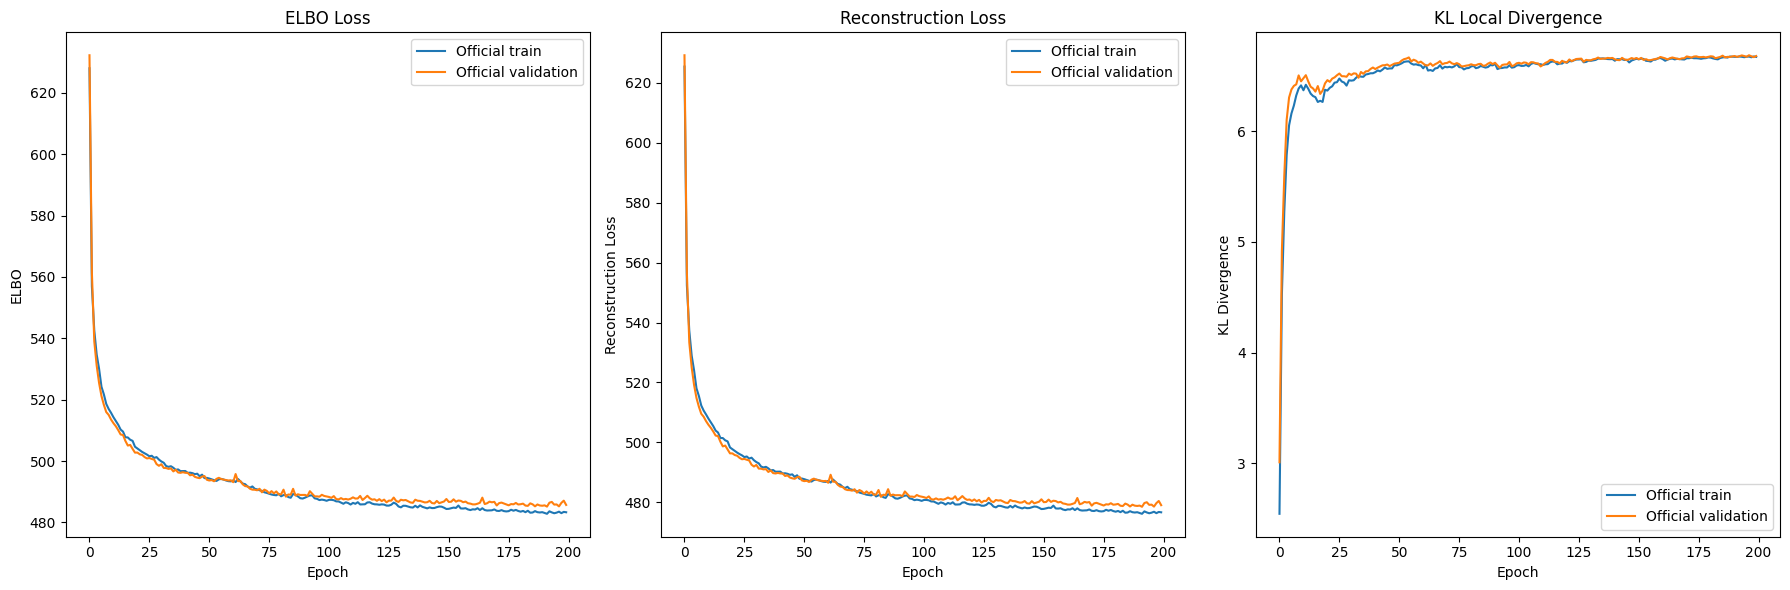

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Plot ELBO Loss
plot_metric(uncoded_hist, "elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0], model_name="Official")
axes[0].legend()

# Plot Reconstruction Loss
plot_metric(uncoded_hist, "reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1], model_name="Official")
axes[1].legend()

# Plot KL Local Divergence
plot_metric(uncoded_hist, "kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2], model_name="Official")
axes[2].legend()

plt.tight_layout()
plt.savefig("loss_metrics_uncoded_kl_weird.png") # Save the figure
plt.show()

KL Local Divergence did something it's not supposed to!

# Testing

In [46]:
# Much simpler model for testing

UncodedSCVI.setup_anndata(adata, layer="counts")
uncoded_model_test = UncodedSCVI(adata, n_latent=10, n_hidden=128, n_layers=2, beta=10, latent_distribution='discrete')
# Train with small number of epochs
uncoded_model_test.train(max_epochs=10, early_stopping=True, plan_kwargs={"lr": 1e-3})

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training:   0%|          | 0/10 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [53]:
latent = uncoded_model_test.get_latent_representation(return_dist=True)
latent

(array([[0.99493545, 0.999     , 0.9839552 , ..., 0.999     , 0.999     ,
         0.9982414 ],
        [0.00217237, 0.98131806, 0.02610311, ..., 0.83658063, 0.001     ,
         0.16036129],
        [0.001     , 0.00389787, 0.9107596 , ..., 0.33266792, 0.001     ,
         0.00251026],
        ...,
        [0.9985246 , 0.99699104, 0.99657613, ..., 0.999     , 0.999     ,
         0.9987644 ],
        [0.001     , 0.999     , 0.001     , ..., 0.01741567, 0.001     ,
         0.00336139],
        [0.00202203, 0.99742067, 0.001     , ..., 0.19276616, 0.00162901,
         0.024703  ]], dtype=float32),
 array([[0.0050389 , 0.00099899, 0.01578736, ..., 0.00099899, 0.00099899,
         0.00175548],
        [0.00216765, 0.01833293, 0.02542174, ..., 0.13671347, 0.000999  ,
         0.13464555],
        [0.000999  , 0.00388268, 0.08127653, ..., 0.22199996, 0.000999  ,
         0.00250396],
        ...,
        [0.00147322, 0.00299991, 0.00341215, ..., 0.00099899, 0.00099899,
         0.00123408

In [31]:
adata.obsm["X_scVI"] = latent[0]
adata.obsm["var_scVI"] = latent[1]
means = pd.DataFrame(latent[0])
means.columns = [f"z_{i}" for i in range(10)]
means.index = adata.obs_names
means.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9
AACTCCCCACGAGAGT-1-HCAHeart7844001,0.001000,0.001000,0.002255,0.992282,0.043221,0.001000,0.001,0.053749,0.999000,0.998370
ATAACGCAGAGCTGGT-1-HCAHeart7829979,0.985440,0.997392,0.995620,0.078826,0.240638,0.992345,0.999,0.661947,0.015388,0.002814
GTCAAGTCATGCCACG-1-HCAHeart7702879,0.997169,0.001000,0.999000,0.001000,0.001000,0.147598,0.001,0.976296,0.999000,0.001000
GGTGATTCAAATGAGT-1-HCAHeart8102858,0.001000,0.001000,0.001000,0.999000,0.999000,0.002706,0.999,0.001000,0.001000,0.999000
AGAGAATTCTTAGCAG-1-HCAHeart8102863,0.001000,0.001000,0.001000,0.999000,0.998184,0.001000,0.999,0.001000,0.681811,0.999000


What is the next step for this representation? Would we actually need to push the values towards 0 or 1? Let's try doing that

In [58]:
latent_bit = uncoded_model_test.get_latent_representation() # only means
# Push values to be either 0 or 1 -> Bit activation
latent_bit = np.where(latent_bit > 0.5, 1, 0)
latent_bit

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [57]:
means = pd.DataFrame(latent_disc)
means.columns = [f"z_{i}" for i in range(10)]
means.index = adata.obs_names
means.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9
AACTCCCCACGAGAGT-1-HCAHeart7844001,1,1,1,0,0,1,0,1,1,1
ATAACGCAGAGCTGGT-1-HCAHeart7829979,0,1,0,1,0,0,1,1,0,0
GTCAAGTCATGCCACG-1-HCAHeart7702879,0,0,1,1,1,1,1,0,0,0
GGTGATTCAAATGAGT-1-HCAHeart8102858,1,0,1,0,1,1,0,1,1,1
AGAGAATTCTTAGCAG-1-HCAHeart8102863,1,0,1,0,1,1,1,1,0,1


In [59]:
# Try to cluster
umap_bit =  umap.UMAP().fit_transform(latent_bit)

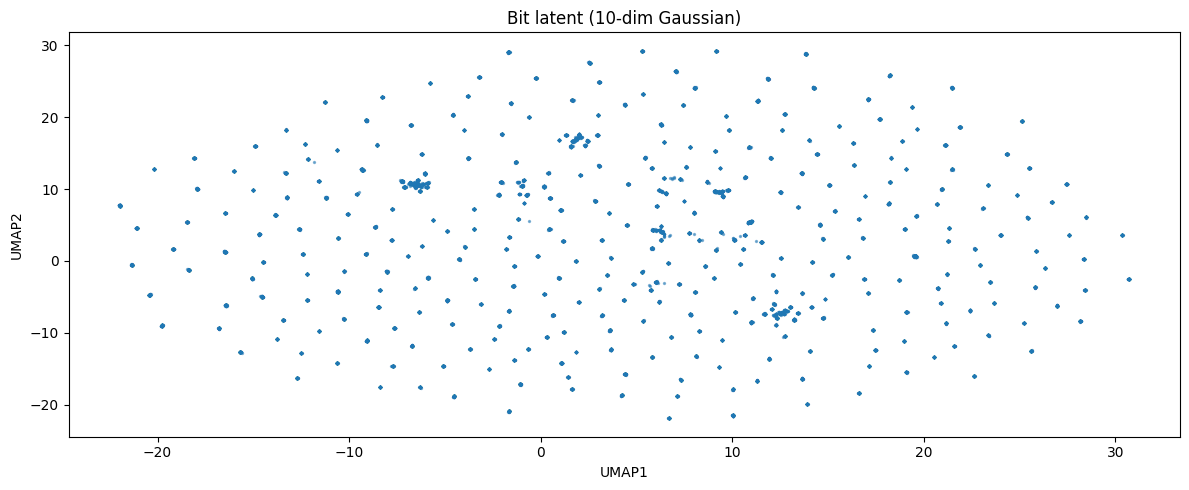

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.scatter(umap_bit[:,0], umap_bit[:,1], s=2, alpha=0.5)
ax.set_title("Bit latent (10-dim Gaussian)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.savefig("UMAP_discrete_0_1.png")
plt.show()

In [65]:
from sklearn.cluster import KMeans

# Assuming 2 clusters for now, similar to UMAP observation
# Try also with 10 clusters from notebook 2
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(means)

# Add cluster labels to adata.obs
adata.obs['kmeans_clusters'] = cluster_labels.astype(str)

print(adata.obs['kmeans_clusters'].value_counts())
adata.obs.head()

kmeans_clusters
4    4694
1    3132
2    2529
0    1897
5    1230
8    1202
3    1159
7    1157
6     896
9     745
Name: count, dtype: int64


,NRP,age_group,cell_source,cell_type,donor,gender,n_counts,n_genes,percent_mito,percent_ribo,...,sample,scrublet_score,source,type,version,cell_states,Used,_scvi_batch,_scvi_labels,kmeans_clusters
AACTCCCCACGAGAGT-1-HCAHeart7844001,Yes,65-70,Sanger-CD45,Myeloid,D6,Male,1420.0,738,0.054930,0.064789,...,HCAHeart7844001,0.113475,CD45+,DCD,V2,LYVE1+MØ1,Yes,0,0,6
ATAACGCAGAGCTGGT-1-HCAHeart7829979,No,70-75,Sanger-Nuclei,Ventricular_Cardiomyocyte,D4,Female,844.0,505,0.001185,0.001185,...,HCAHeart7829979,0.085546,Nuclei,DCD,V2,vCM1,Yes,0,0,0
GTCAAGTCATGCCACG-1-HCAHeart7702879,Yes,60-65,Sanger-Nuclei,Fibroblast,D2,Male,1491.0,862,0.000000,0.005366,...,HCAHeart7702879,0.197861,Nuclei,DCD,V2,FB2,Yes,0,0,5
GGTGATTCAAATGAGT-1-HCAHeart8102858,Yes,60-65,Sanger-CD45,Endothelial,D11,Female,2167.0,1115,0.064144,0.027227,...,HCAHeart8102858,0.113475,CD45+,DCD,V3,EC10_CMC-like,Yes,0,0,1
AGAGAATTCTTAGCAG-1-HCAHeart8102863,Yes,60-65,Sanger-Cells,Endothelial,D11,Female,7334.0,2505,0.093537,0.040496,...,HCAHeart8102863,0.132150,Cells,DCD,V3,EC5_art,Yes,0,0,1


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: discrete.
Training status: Trained
Model's adata is minified?: False

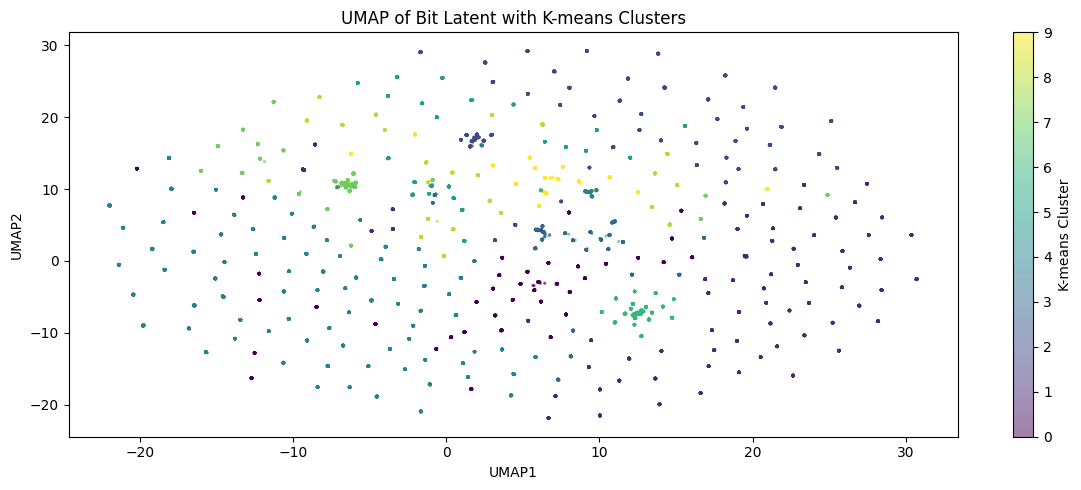

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
# Assuming 'umap_bit' and 'adata.obs['kmeans_clusters']' are already defined
scatter = ax.scatter(umap_bit[:,0], umap_bit[:,1], s=2, alpha=0.5, c=adata.obs['kmeans_clusters'].astype(int), cmap='viridis')
ax.set_title("UMAP of Bit Latent with K-means Clusters")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# Add a color bar to show cluster mapping
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('K-means Cluster')

plt.tight_layout()
plt.savefig("UMAP_discrete_kmeans_clusters.png")
plt.show()

In [47]:
uncoded_hist = uncoded_model_test.history

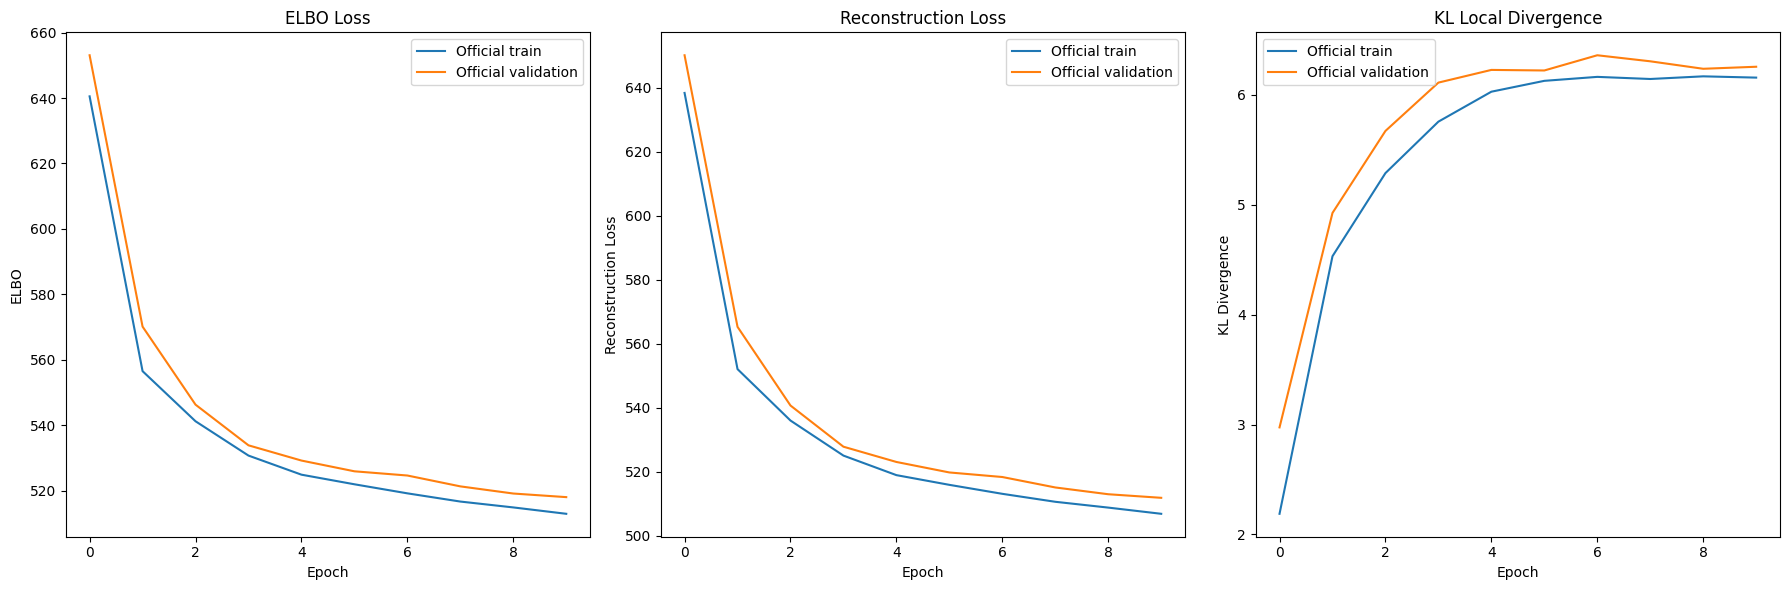

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Plot ELBO Loss
plot_metric(uncoded_hist, "elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0], model_name="Official")
axes[0].legend()

# Plot Reconstruction Loss
plot_metric(uncoded_hist, "reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1], model_name="Official")
axes[1].legend()

# Plot KL Local Divergence
plot_metric(uncoded_hist, "kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2], model_name="Official")
axes[2].legend()

plt.tight_layout()
plt.savefig("loss_metrics_uncoded_kl_weird.png") # Save the figure
plt.show()

## Quantitative tests

In [36]:
# 1. Check that the model can reconstruct held‑out data and loss is finite
uncoded_model_test.module.eval()
cont_model.module.eval()
test_loader = uncoded_model_test._make_data_loader(adata=adata, batch_size=128)
batch = next(iter(test_loader))
with torch.no_grad():
    # Discrete model
    inf_out = uncoded_model_test.module.inference(batch[REGISTRY_KEYS.X_KEY])
    gen_out = uncoded_model_test.module.generative(inf_out["z"], library=batch["library"])
    loss_dict = uncoded_model_test.module.loss(batch, inf_out, gen_out)
    print("Discrete model ELBO components:", loss_dict)

# 2. Assert reconstruction loss is reasonable (lower than a random guess?)
# We'll just check that it is finite and positive
assert torch.isfinite(loss_dict["loss"]), "Loss is not finite!"
assert loss_dict["reconstruction_loss"] > 0, "Reconstruction loss should be >0"
print("✓ Loss checks passed.")

TypeError: UncodedSCVIModule._regular_inference() missing 1 required positional argument: 'batch_index'

In [37]:
# 3. Check that information bits are mostly in [0,1] and not collapsed
info_rep = uncoded_model_test.get_latent_representation()
print(f"Info bits min/max: {info_rep.min():.4f} / {info_rep.max():.4f}") # Because they were clamped by the sigmoid
print(f"Average probability per bit: {info_rep.mean(axis=0)}")
# Not extremely close to 0 or 1 everywhere
assert info_rep.min() > 0.0 and info_rep.max() < 1.0
print("✓ Info bits are well‑behaved.")

Info bits min/max: 0.0010 / 0.9990
Average probability per bit: [0.7269292  0.3424066  0.7753642  0.52736986 0.50252014 0.667694
 0.6219004  0.52751166 0.47687218 0.319364  ]
✓ Info bits are well‑behaved.


In [38]:
# 4. Verify the coding/decoding logic on a real batch
x_batch = batch[REGISTRY_KEYS.X_KEY]
with torch.no_grad():
    h = uncoded_model_test.module.z_encoder(x_batch)
    qc = torch.sigmoid(h[:, :uncoded_model_test.module.n_code] / uncoded_model_test.module.beta)
    # Soft decode
    log_pm1 = torch.log(qc + 1e-9) @ uncoded_model_test.module.H
    log_pm0 = torch.log(1 - qc + 1e-9) @ uncoded_model_test.module.H
    qm_est = torch.softmax(torch.stack([log_pm0, log_pm1], dim=-1), dim=-1)[..., 1]
    # Re-encode using G: code probabilities should match qc approximately
    qc_recon = qm_est @ uncoded_model_test.module.G
    # Check correlation
    corr = np.corrcoef(qc.numpy().flatten(), qc_recon.numpy().flatten())[0,1]
    print(f"Correlation between original q(c) and re‑encoded q(m)@G: {corr:.3f}")
    assert corr > 0.5, "Re‑encoding consistency too low"
    print("✓ Coding/decoding consistency passed.")

AttributeError: 'UncodedSCVIModule' object has no attribute 'n_code'

In [39]:
# 5. Compare ELBO between continuous and discrete (on same batch)
# Continuous model uses Gaussian latent; we can compute its ELBO on the test batch
with torch.no_grad():
    inf_cont = cont_model.module.inference(batch[REGISTRY_KEYS.X_KEY])
    gen_cont = cont_model.module.generative(inf_cont["z"], library=batch["library"])
    loss_cont = cont_model.module.loss(batch, inf_cont, gen_cont)
print(f"Continuous ELBO: {loss_cont['loss'].item():.4f}")
print(f"Discrete ELBO  : {loss_dict['loss'].item():.4f}")
# Not a strict assertion, but we expect discrete to be competitive
print("✓ ELBO comparison complete (discrete model may be slightly higher due to different latent size).")

TypeError: VAE._regular_inference() missing 1 required positional argument: 'batch_index'

## UMAP Plot - Compare to baseline

In [32]:
# Extract latent representations
# Continuous model

latent_cont = cont_model.get_latent_representation()
# Discrete model (information‑bit marginals)
latent_disc = uncoded_model_test.get_latent_representation()
print(f"Continuous shape: {latent_cont.shape}")
print(f"Discrete (info) shape: {latent_disc.shape}")

Continuous shape: (18641, 10)
Discrete (info) shape: (18641, 10)


In [33]:
# Compute UMAP for both
umap_cont = umap.UMAP().fit_transform(latent_cont)
umap_disc = umap.UMAP().fit_transform(latent_disc)


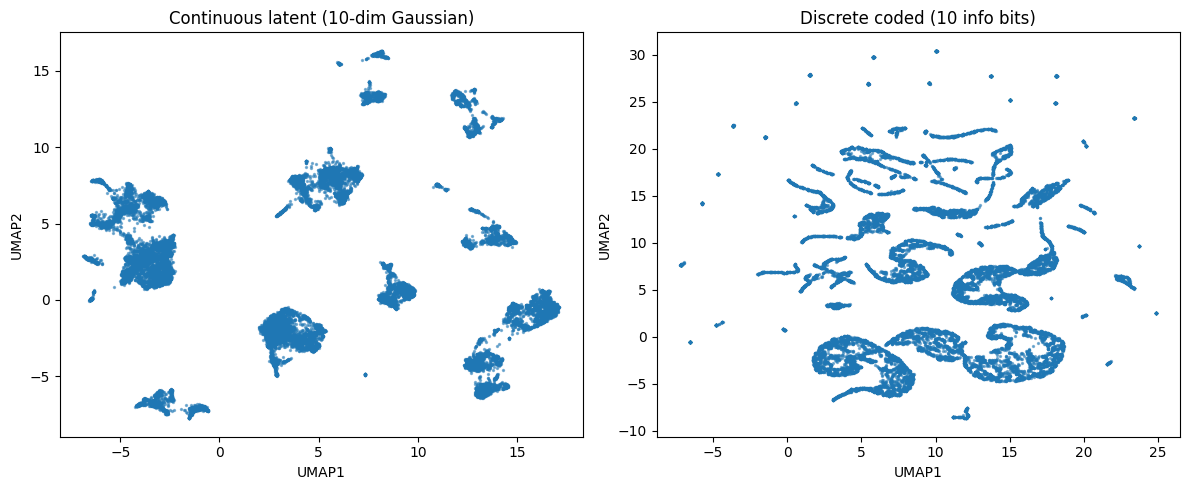

In [41]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(umap_cont[:,0], umap_cont[:,1], s=2, alpha=0.5)
axes[0].set_title("Continuous latent (10-dim Gaussian)")
axes[1].scatter(umap_disc[:,0], umap_disc[:,1], s=2, alpha=0.5)
axes[1].set_title("Discrete coded (10 info bits)")
for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.savefig("UMAP_cont_uncoded_bad.png")
plt.show()